<a href="https://colab.research.google.com/github/maheshjw/Extracting-Insights-from-Amazon-Beauty-Reviews/blob/main/FINAL__BA810_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Introduction
We used the Airbnb data for the city of Amsterdam focusing on the physical ammenities that impact the reviews for the listings. Our data is from Inside Airbnb from September 11th, 2025. The initial data set had 79 columns with over 10,000 rows. However, we reduced the dataset to a set of features applicable to driving the review rating.


##Colab Notebook Link
https://colab.research.google.com/drive/1ZqXnzZWXLbANUhCV-sfu2QCkyqm_RP82?usp=drive_link

#**Table of Contents**

1. [Cleaning Phase](#cleaning-phase)
2. [Model Preparation](#model-preparation)
3. [Linear Regression](#linear-regression)
4. [Logistic Regression](#logistic-regression)
5. [Ensemble](#ensemble)
6. [K-fold Cross Validation & Confusion Matrix](#k-fold-cross-validation--confusion-matrix)
7. [Regularization](#ridge-regression)
8. [Lasso Regression](#lasso-regression)
9. [Bootstrap](#bootstrap)
10. [Feature Selection](#feature-selection)
11. [Hyperparameter Search](#hyperparameter-search)
11. [Support Vector Machine](#suppot-vector-machine)
12. [Decision Tree and Class Imbalance Management](decision-tree-and-class-imbalance-management)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd


file_path = '/content/drive/MyDrive/BA810- Airbnb Project/listings 2.csv'
airbnb = pd.read_csv(file_path)

# check the first few rows
airbnb.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,...,4.93,4.90,4.78,0363 974D 4986 7411 88D8,f,1,0,1,0,1.87
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,3.99
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.92,4.87,4.79,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,4.81
3,44391,https://www.airbnb.com/rooms/44391,20250911031321,2025-09-11,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,The appartment is located in the city centre. ...,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,f,1,1,0,0,0.23
4,48373,https://www.airbnb.com/rooms/48373,20250911031321,2025-09-11,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,Apartment is located between Amsterdamse Bos a...,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,f,1,1,0,0,0.19


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10480 non-null  int64  
 1   listing_url                                   10480 non-null  object 
 2   scrape_id                                     10480 non-null  int64  
 3   last_scraped                                  10480 non-null  object 
 4   source                                        10480 non-null  object 
 5   name                                          10480 non-null  object 
 6   description                                   10132 non-null  object 
 7   neighborhood_overview                         5192 non-null   object 
 8   picture_url                                   10480 non-null  object 
 9   host_id                                       10480 non-null 

In [ ]:
airbnb[65:71].describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,6.000000,6.000000e+00,6.000000e+00,6.000000,6.000000,0.0,6.000000,6.000000,6.000000,3.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.0,6.000000
mean,483746.833333,2.025091e+13,2.252472e+06,1.166667,1.833333,NaN,52.362855,4.877630,3.000000,1.166667,...,4.833333,4.916667,4.946667,4.815000,4.738333,1.166667,0.833333,0.333333,0.0,0.583333
std,22661.821837,0.000000e+00,3.113022e+05,0.408248,0.983192,NaN,0.008861,0.023948,1.095445,0.288675,...,0.099130,0.070048,0.083347,0.224566,0.164124,0.408248,0.752773,0.516398,0.0,0.762828
min,450767.000000,2.025091e+13,1.645998e+06,1.000000,1.000000,NaN,52.350900,4.832930,2.000000,1.000000,...,4.720000,4.790000,4.780000,4.380000,4.490000,1.000000,0.000000,0.000000,0.0,0.090000
25%,467700.500000,2.025091e+13,2.253156e+06,1.000000,1.000000,NaN,52.356687,4.875375,2.000000,1.000000,...,4.762500,4.907500,4.962500,4.800000,4.632500,1.000000,0.250000,0.000000,0.0,0.212500
50%,490366.000000,2.025091e+13,2.346290e+06,1.000000,1.500000,NaN,52.363985,4.882290,3.000000,1.000000,...,4.825000,4.935000,4.970000,4.910000,4.805000,1.000000,1.000000,0.000000,0.0,0.350000
75%,501960.000000,2.025091e+13,2.439298e+06,1.000000,2.750000,NaN,52.368575,4.891365,4.000000,1.250000,...,4.887500,4.940000,4.992500,4.952500,4.842500,1.000000,1.000000,0.750000,0.0,0.405000
max,505012.000000,2.025091e+13,2.483843e+06,2.000000,3.000000,NaN,52.373900,4.900810,4.000000,1.500000,...,4.980000,5.000000,5.000000,4.960000,4.900000,2.000000,2.000000,1.000000,0.0,2.120000


In [ ]:
airbnb[['host_is_superhost','review_scores_rating', 'review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']].describe()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,9383.000000,9383.000000,9382.000000,9383.000000,9383.000000,9383.000000,9383.000000
mean,4.844096,4.853297,4.777811,4.894101,4.907071,4.817007,4.653918
std,0.257871,0.251559,0.317948,0.215202,0.216665,0.231716,0.323497
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
25%,4.790000,4.800000,4.690000,4.870000,4.900000,4.730000,4.530000
50%,4.920000,4.920000,4.870000,4.970000,5.000000,4.890000,4.710000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.850000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
airbnb[['host_is_superhost','review_scores_rating', 'review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            10365 non-null  object 
 1   review_scores_rating         9383 non-null   float64
 2   review_scores_accuracy       9383 non-null   float64
 3   review_scores_cleanliness    9382 non-null   float64
 4   review_scores_checkin        9383 non-null   float64
 5   review_scores_communication  9383 non-null   float64
 6   review_scores_location       9383 non-null   float64
 7   review_scores_value          9383 non-null   float64
dtypes: float64(7), object(1)
memory usage: 655.1+ KB


# **1. Cleaning Phase**

In [ ]:
cols_to_drop = ['name','room_type','host_location', 'host_response_time', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'price', 'minimum_nights', 'availability_365', 'number_of_reviews', 'id', 'listing_url', 'scrape_id', 'last_scraped', 'source',
                'description', 'neighborhood_overview', 'picture_url',
                'host_id', 'host_url', 'host_name', 'host_about',
                'host_response_rate', 'host_acceptance_rate',
                'host_thumbnail_url','host_picture_url', 'host_neighbourhood',
                'host_listings_count', 'host_verifications',
                'host_has_profile_pic','host_identity_verified',
                'neighbourhood_group_cleansed', 'bathrooms', 'bathrooms_text',
                'beds', 'maximum_nights', 'minimum_minimum_nights',
                'maximum_minimum_nights', 'minimum_maximum_nights',
                'maximum_maximum_nights', 'minimum_nights_avg_ntm',
                'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
                'availability_30', 'availability_60', 'availability_90',
                'calendar_last_scraped', 'number_of_reviews_ltm',
                'number_of_reviews_l30d', 'availability_eoy',
                'number_of_reviews_ly', 'estimated_occupancy_l365d',
                'estimated_revenue_l365d', 'first_review', 'last_review',
                'license', 'instant_bookable', 'calculated_host_listings_count',
                'calculated_host_listings_count_entire_homes',
                'calculated_host_listings_count_private_rooms',
                'calculated_host_listings_count_shared_rooms',
                'reviews_per_month', 'neighbourhood']

airbnb_cleaned = airbnb.drop(columns=cols_to_drop)

In [ ]:
airbnb_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_since                   10477 non-null  object 
 1   host_total_listings_count    10477 non-null  float64
 2   neighbourhood_cleansed       10480 non-null  object 
 3   property_type                10480 non-null  object 
 4   amenities                    10480 non-null  object 
 5   review_scores_rating         9383 non-null   float64
 6   review_scores_accuracy       9383 non-null   float64
 7   review_scores_cleanliness    9382 non-null   float64
 8   review_scores_checkin        9383 non-null   float64
 9   review_scores_communication  9383 non-null   float64
 10  review_scores_location       9383 non-null   float64
 11  review_scores_value          9383 non-null   float64
dtypes: float64(8), object(4)
memory usage: 982.6+ KB


In [ ]:
airbnb_cleaned.describe()

,host_total_listings_count,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,10477.000000,9383.000000,9383.000000,9382.000000,9383.000000,9383.000000,9383.000000,9383.000000
mean,5.991887,4.844096,4.853297,4.777811,4.894101,4.907071,4.817007,4.653918
std,61.183451,0.257871,0.251559,0.317948,0.215202,0.216665,0.231716,0.323497
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
25%,1.000000,4.790000,4.800000,4.690000,4.870000,4.900000,4.730000,4.530000
50%,1.000000,4.920000,4.920000,4.870000,4.970000,5.000000,4.890000,4.710000
75%,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.850000
max,1655.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
airbnb_cleaned.isnull().sum().sort_values(ascending=False)

,0
review_scores_cleanliness,1098
review_scores_checkin,1097
review_scores_rating,1097
review_scores_accuracy,1097
review_scores_location,1097
review_scores_communication,1097
review_scores_value,1097
host_since,3
host_total_listings_count,3
neighbourhood_cleansed,0


In [ ]:
import ast
from collections import Counter

# Parse the amenities column (convert string → Python list)
amenities = airbnb_cleaned['amenities'].dropna().apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Count all amenities
counter = Counter()
for items in amenities:
    counter.update(items)

# Top 5 most common amenities
top_5 = counter.most_common(5)
top_5

[('Smoke alarm', 9506),
 ('Wifi', 9484),
 ('Kitchen', 8860),
 ('Hot water', 8399),
 ('Essentials', 7769)]

**ESSENTIALS:**

Toilet paper

Soap (for hands and body)

One towel per guest

One pillow per guest

Linens for each guest bed

In [ ]:
# One-hot encode for top 5 amenities
for amenity, _ in top_5:
    airbnb_cleaned[f'has_{amenity.replace(" ", "_").lower()}'] = amenities.apply(lambda x: 1 if amenity in x else 0)

In [ ]:
import pandas as pd

# convert to datetime
airbnb_cleaned['host_since'] = pd.to_datetime(airbnb_cleaned['host_since'], errors='coerce')

# create a numerical feature
today = pd.Timestamp('today')
airbnb_cleaned['host_tenure_days'] = (today - airbnb_cleaned['host_since']).dt.days

# drop the original string column
airbnb_cleaned = airbnb_cleaned.drop(columns=['host_since'])

host_since to host_tenure_days

In [ ]:
from collections import Counter

# Step 1: Standardize the text (important for accurate counting)
airbnb_cleaned['property_type'] = (
    airbnb_cleaned['property_type']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Step 2: Count frequency of each property_type
counter = Counter(airbnb_cleaned['property_type'])

# Step 3: Get the top 3 most common property types
top_3_properties = [ptype for ptype, count in counter.most_common(3)]
print("Top 3 properties:", top_3_properties)

# Step 4: One-hot encode only the top 3
for ptype in top_3_properties:
    col_name = f"pt_{ptype.replace(' ', '_')}"
    airbnb_cleaned[col_name] = (airbnb_cleaned['property_type'] == ptype).astype(int)

# Step 5: (Optional) Drop the original column
# airbnb_cleaned = airbnb_cleaned.drop(columns=['property_type'])


Top 3 properties: ['entire rental unit', 'entire condo', 'entire home']


one hot encoding property type (top 3)

In [ ]:
from collections import Counter

# Step 1: Standardize the text (important for accurate counting)
airbnb_cleaned['neighbourhood_cleansed'] = (
    airbnb_cleaned['neighbourhood_cleansed']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Step 2: Count frequency of each neighbourhood_cleansed
counter = Counter(airbnb_cleaned['neighbourhood_cleansed'])

# Step 3: Get the top 3 most common property types
top_5_neighborhoods = [ptype for ptype, count in counter.most_common(5)]
print("Top 5 neighbourhood:", top_5_neighborhoods)

# Step 4: One-hot encode only the top 3
for ptype in top_5_neighborhoods:
    col_name = f"nh_{ptype.replace(' ', '_')}"
    airbnb_cleaned[col_name] = (airbnb_cleaned['neighbourhood_cleansed'] == ptype).astype(int)

# Step 5: (Optional) Drop the original column
# airbnb_cleaned = airbnb_cleaned.drop(columns=['property_type'])


Top 5 neighbourhood: ['de baarsjes - oud-west', 'centrum-west', 'de pijp - rivierenbuurt', 'centrum-oost', 'westerpark']


one hot encoding neighbourhood_cleansed (top 5)

In [ ]:
airbnb_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_total_listings_count    10477 non-null  float64
 1   neighbourhood_cleansed       10480 non-null  object 
 2   property_type                10480 non-null  object 
 3   amenities                    10480 non-null  object 
 4   review_scores_rating         9383 non-null   float64
 5   review_scores_accuracy       9383 non-null   float64
 6   review_scores_cleanliness    9382 non-null   float64
 7   review_scores_checkin        9383 non-null   float64
 8   review_scores_communication  9383 non-null   float64
 9   review_scores_location       9383 non-null   float64
 10  review_scores_value          9383 non-null   float64
 11  has_smoke_alarm              10480 non-null  int64  
 12  has_wifi                     10480 non-null  int64  
 13  has_kitchen     

#**2. Model Preparation**

In [ ]:
#DATA IMPORT & COLUMN SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sklearn

from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve,
    StratifiedKFold, GridSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, MinMaxScaler,
    FunctionTransformer, KBinsDiscretizer, OrdinalEncoder, Binarizer
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    roc_curve
)

if "airbnb_cleaned" not in globals():
    airbnb_cleaned = airbnb.copy()

if 'price' in airbnb_cleaned.columns and airbnb_cleaned['price'].dtype == object:
    airbnb_cleaned['price'] = (
        airbnb_cleaned['price']
        .replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

if 'review_scores_rating' in airbnb_cleaned.columns:
    airbnb_cleaned['review_scores_rating'] = pd.to_numeric(
        airbnb_cleaned['review_scores_rating'], errors='coerce'
    )
    rating_max = airbnb_cleaned['review_scores_rating'].dropna().max()
    if rating_max is not None and rating_max <= 5.0:
        airbnb_cleaned['review_scores_rating'] *= 20.0

numeric_candidates = [
    'accommodates','bedrooms','bathrooms','beds','latitude','longitude',
    'minimum_nights','availability_365','number_of_reviews','reviews_per_month',
    'price','host_total_listings_count','calculated_host_listings_count'
]

categorical_candidates = [
    'property_type','room_type','host_response_time',
    'host_is_superhost','neighbourhood_cleansed'
]

base_numeric_cols = [c for c in numeric_candidates if c in airbnb_cleaned.columns]
base_categorical_cols = [c for c in categorical_candidates if c in airbnb_cleaned.columns]

engineered_numeric_prefixes = ("has_", "pt_", "nh_")
engineered_numeric_cols = [
    c for c in airbnb_cleaned.columns
    if c.startswith(engineered_numeric_prefixes)
]

if "host_tenure_days" in airbnb_cleaned.columns:
    engineered_numeric_cols.append("host_tenure_days")

numeric_cols = sorted(set(base_numeric_cols + engineered_numeric_cols))
categorical_cols = base_categorical_cols

print(f"Using {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Using 15 numeric and 2 categorical features.
Numeric: ['has_essentials', 'has_hot_water', 'has_kitchen', 'has_smoke_alarm', 'has_wifi', 'host_tenure_days', 'host_total_listings_count', 'nh_centrum-oost', 'nh_centrum-west', 'nh_de_baarsjes_-_oud-west', 'nh_de_pijp_-_rivierenbuurt', 'nh_westerpark', 'pt_entire_condo', 'pt_entire_home', 'pt_entire_rental_unit']
Categorical: ['property_type', 'neighbourhood_cleansed']


# **3. Linear Regression**

We used Linear Regression as a baseline model because it provides a simple, interpretable way to understand linear relationships between listing characteristics and review scores. It allows us to directly quantify how each numerical or categorical feature influences ratings through coefficients, confidence intervals, and significance tests. Linear Regression also helps determine whether a linear pattern even exists before moving to more complex models.

In [ ]:
#Linear Regression Setup
airbnb_cleaned['review_scores_rating'] = pd.to_numeric(
    airbnb_cleaned['review_scores_rating'], errors='coerce'
)

target_col = 'review_scores_rating'
airbnb_lin = airbnb_cleaned[numeric_cols + categorical_cols + [target_col]].dropna(subset=[target_col])

X = airbnb_lin[numeric_cols + categorical_cols]
y = airbnb_lin[target_col]

onehot_kwargs = {"handle_unknown": "ignore"}
if sklearn.__version__ >= "1.4":
    onehot_kwargs["sparse_output"] = True
else:
    onehot_kwargs["sparse"] = True

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(**onehot_kwargs))
])

prep_pipeline = ColumnTransformer(
    [("num", num_pipe, numeric_cols),
     ("cat", cat_pipe, categorical_cols)],
    remainder="drop",
    sparse_threshold=0.3,
    verbose_feature_names_out=False,
)

In [ ]:
#Linear Regression — Fit & Evaluation

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_null = np.full_like(y_te, fill_value=y_tr.mean(), dtype=float)
rmse_null = np.sqrt(mean_squared_error(y_te, y_null))

lin_pipe = Pipeline([
    ("prep", prep_pipeline),
    ("lin", LinearRegression())
]).fit(X_tr, y_tr)

y_hat_te = lin_pipe.predict(X_te)
y_hat_tr = lin_pipe.predict(X_tr)

rmse_te = np.sqrt(mean_squared_error(y_te, y_hat_te))
rmse_tr = np.sqrt(mean_squared_error(y_tr, y_hat_tr))
r2_te = r2_score(y_te, y_hat_te)
r2_tr = r2_score(y_tr, y_hat_tr)

tss = np.sum((y_te - y_te.mean())**2)
rss = np.sum((y_te - y_hat_te)**2)

Xp_tr = prep_pipeline.fit_transform(X_tr)
p_eff = Xp_tr.shape[1]
n_te = len(y_te)
se_reg = np.sqrt(rss / (n_te - p_eff - 1)) if (n_te - p_eff - 1) > 0 else np.nan

print("=== Linear Regression (Test) ===")
print(f"Null RMSE: {rmse_null:.3f}")
print(f"RMSE (test): {rmse_te:.3f} | R^2 (test): {r2_te:.3f}")
print(f"RMSE (train): {rmse_tr:.3f} | R^2 (train): {r2_tr:.3f}")
print(f"TSS (test): {tss:.2f} | RSS (test): {rss:.2f} | SE: {se_reg:.3f}")

Xp_tr_dense = Xp_tr.toarray() if hasattr(Xp_tr, "toarray") else Xp_tr
X_sm = sm.add_constant(Xp_tr_dense, has_constant='add')
ols = sm.OLS(y_tr.values, X_sm).fit()

print("\n=== OLS summary (truncated) ===")
print("\n".join(ols.summary().as_text().splitlines()[:15]))

ci = pd.DataFrame(ols.conf_int(), columns=["lower", "upper"])
print("\n95% CI (first 10 coefficients):")
print(ci.head(10))

cv_rmse = -cross_val_score(
    lin_pipe, X, y, cv=5, scoring="neg_root_mean_squared_error"
)
print("\n=== 5-fold CV ===")
print(f"CV RMSE mean: {cv_rmse.mean():.3f} | std: {cv_rmse.std():.3f}")

=== Linear Regression (Test) ===
Null RMSE: 5.170
RMSE (test): 4.981 | R^2 (test): 0.072
RMSE (train): 4.917 | R^2 (train): 0.090
TSS (test): 50172.81 | RSS (test): 46564.57 | SE: 5.113

=== OLS summary (truncated) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     8.625
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           5.33e-98
Time:                        00:53:53   Log-Likelihood:                -22605.
No. Observations:                7506   AIC:                         4.538e+04
Df Residuals:                    7420   BIC:                         4.598e+04
Df Model:                          85                                         
Covariance Type:            nonrobust                                 

The model achieved a low R² on both train and test (≈0.07–0.09), indicating that only a small portion of rating variability can be explained with linear relationships. Confidence intervals show several coefficients are significant, but effect sizes are small—meaning no single feature strongly drives ratings in a linear way. The takeaway is that Airbnb ratings exhibit nonlinear patterns and ceiling effects, making linear regression an informative but limited modeling approach.

# **4. Logistic Regression**

**Logistic Regression:** <br>
Logistic Regression was chosen because it is the standard interpretable method for modeling binary outcomes—in this case, identifying whether a listing achieves a high rating (≥100). It allows us to measure the probability that a listing is highly rated, while still offering coefficient interpretability and the ability to apply threshold tuning to balance precision and recall. It also aligns well with the business decision-making perspective: “What features increase the likelihood of being a top-rated listing?”<br>

**Naive Bayes Models (Gaussian & Multinomial):**<br>
Naive Bayes models were used because they provide a fast, probabilistic approach to classification and serve as a non-linear baseline to compare against logistic regression. GaussianNB handles continuous variables while MultinomialNB handles transformed/binned features and count-like indicators, making them useful in mixed numerical–categorical datasets like Airbnb listings. Their strong assumptions (feature independence) make them easy to interpret, even if sometimes oversimplified.<br>

**K-Nearest Neighbor (KNN):**<br>
KNN was used because it is a flexible, non-parametric method that does not assume linearity or independence among features. It classifies listings based on similarity rather than algebraic relationships, which is useful in a dataset where local patterns matter (e.g., similar neighborhoods, similar amenities). It also serves as a benchmark against both linear and probabilistic models.

In [ ]:
#Classification Setup: Logistic + Naive Bayes + KNN

airbnb_cleaned['review_scores_rating'] = pd.to_numeric(
    airbnb_cleaned['review_scores_rating'], errors='coerce'
)

ratings = airbnb_cleaned['review_scores_rating'].dropna()
candidate_thresholds = [100, 99, 98, 97, 96, 95, 94, 93, 92, 90]
chosen_threshold = None
for t in candidate_thresholds:
    pr = (ratings >= t).mean()
    if 0.08 <= pr <= 0.5:
        chosen_threshold = float(t)
        break
if chosen_threshold is None:
    chosen_threshold = float(ratings.quantile(0.75))

airbnb_clf = airbnb_cleaned[
    numeric_cols + categorical_cols + ['review_scores_rating']
].dropna(subset=['review_scores_rating']).copy()

airbnb_clf['high_rating'] = (
    airbnb_clf['review_scores_rating'] >= chosen_threshold
).astype(int)

print(
    f"Chosen threshold = {chosen_threshold:.2f} | class counts:",
    airbnb_clf['high_rating'].value_counts().to_dict()
)

Xc = airbnb_clf[numeric_cols + categorical_cols]
yc = airbnb_clf['high_rating']

onehot_kwargs = {"handle_unknown": "ignore"}
if sklearn.__version__ >= "1.4":
    onehot_kwargs["sparse_output"] = True
else:
    onehot_kwargs["sparse"] = True

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(**onehot_kwargs))
])

prep_pipeline = ColumnTransformer(
    [("num", num_pipe, numeric_cols),
     ("cat", cat_pipe, categorical_cols)],
    verbose_feature_names_out=False
)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

Chosen threshold = 100.00 | class counts: {0: 5746, 1: 3637}


In [ ]:
#Logistic Regression (Baseline + GridSearchCV)

logit_base = Pipeline([
    ("prep", prep_pipeline),
    ("clf", LogisticRegression(max_iter=1000))
]).fit(Xc_tr, yc_tr)

proba_base = logit_base.predict_proba(Xc_te)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print(f"\n=== Logistic Regression (>= {chosen_threshold:.2f}) — Baseline ===")
print(f"Accuracy : {accuracy_score(yc_te, pred_base):.3f}")
print(f"ROC-AUC  : {roc_auc_score(yc_te, proba_base):.3f}")
print(f"Precision: {precision_score(yc_te, pred_base, zero_division=0):.3f}")
print(f"Recall   : {recall_score(yc_te, pred_base, zero_division=0):.3f}")
print("Confusion Matrix:\n", confusion_matrix(yc_te, pred_base))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "clf__C": [0.1, 1, 3, 10, 30],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "liblinear"]
}

logit_gs = GridSearchCV(
    Pipeline([
        ("prep", prep_pipeline),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    param_grid,
    cv=cv,
    scoring="roc_auc"
).fit(Xc_tr, yc_tr)

best_logit = logit_gs.best_estimator_
proba_gs = best_logit.predict_proba(Xc_te)[:, 1]
pred_gs = (proba_gs >= 0.5).astype(int)

print("\n=== Logistic Regression — GridSearchCV ===")
print("Best params:", logit_gs.best_params_)
print(f"Accuracy : {accuracy_score(yc_te, pred_gs):.3f}")
print(f"ROC-AUC  : {roc_auc_score(yc_te, proba_gs):.3f}")


=== Logistic Regression (>= 100.00) — Baseline ===
Accuracy : 0.664
ROC-AUC  : 0.714
Precision: 0.606
Recall   : 0.386
Confusion Matrix:
 [[966 183]
 [447 281]]

=== Logistic Regression — GridSearchCV ===
Best params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Accuracy : 0.664
ROC-AUC  : 0.712


In [ ]:
#Threshold Tuning + Naive Bayes Models

fpr, tpr, thr = roc_curve(yc_te, proba_gs)
thr_star = thr[np.argmax(tpr - fpr)]
pred_tuned = (proba_gs >= thr_star).astype(int)

print(f"\nTuned threshold = {thr_star:.3f}")
print(f"Accuracy : {accuracy_score(yc_te, pred_tuned):.3f}")
print(f"Precision: {precision_score(yc_te, pred_tuned, zero_division=0):.3f}")
print(f"Recall   : {recall_score(yc_te, pred_tuned, zero_division=0):.3f}")
print("Confusion Matrix:\n", confusion_matrix(yc_te, pred_tuned))

from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler

ToDense = FunctionTransformer(lambda A: A.toarray() if hasattr(A, "toarray") else A)

num_gauss = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_gauss = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
prep_gauss = ColumnTransformer(
    [("num", num_gauss, numeric_cols),
     ("cat", cat_gauss, categorical_cols)],
    verbose_feature_names_out=False
)

nb_gauss = Pipeline([
    ("prep", prep_gauss),
    ("dense", ToDense),
    ("clf", GaussianNB())
]).fit(Xc_tr, yc_tr)

pred_nb_g = nb_gauss.predict(Xc_te)
print("\n=== Naive Bayes — GaussianNB ===")
print(f"Accuracy : {accuracy_score(yc_te, pred_nb_g):.3f}")
try:
    print(f"ROC-AUC  : {roc_auc_score(yc_te, nb_gauss.predict_proba(Xc_te)[:, 1]):.3f}")
except Exception:
    pass
print("Confusion Matrix:\n", confusion_matrix(yc_te, pred_nb_g))

num_multi = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("minmax", MinMaxScaler())
])
cat_multi = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
prep_multi = ColumnTransformer(
    [("num", num_multi, numeric_cols),
     ("cat", cat_multi, categorical_cols)],
    verbose_feature_names_out=False
)

nb_multi = Pipeline([
    ("prep", prep_multi),
    ("clf", MultinomialNB())
]).fit(Xc_tr, yc_tr)

pred_nb_m = nb_multi.predict(Xc_te)
print("\n=== Naive Bayes — MultinomialNB ===")
print(f"Accuracy : {accuracy_score(yc_te, pred_nb_m):.3f}")
try:
    print(f"ROC-AUC  : {roc_auc_score(yc_te, nb_multi.predict_proba(Xc_te)[:, 1]):.3f}")
except Exception:
    pass
print("Confusion Matrix:\n", confusion_matrix(yc_te, pred_nb_m))


Tuned threshold = 0.402
Accuracy : 0.643
Precision: 0.530
Recall   : 0.709
Confusion Matrix:
 [[691 458]
 [212 516]]

=== Naive Bayes — GaussianNB ===
Accuracy : 0.452
ROC-AUC  : 0.569
Confusion Matrix:
 [[ 132 1017]
 [  12  716]]

=== Naive Bayes — MultinomialNB ===
Accuracy : 0.621
ROC-AUC  : 0.680
Confusion Matrix:
 [[702 447]
 [264 464]]


In [ ]:
#K-Nearest Neighbors (GridSearchCV)

knn_gs = GridSearchCV(
    Pipeline([
        ("prep", prep_pipeline),
        ("clf", KNeighborsClassifier())
    ]),
    {
        "clf__n_neighbors": [3, 5, 7, 9, 11],
        "clf__weights": ["uniform", "distance"]
    },
    cv=cv,
    scoring="accuracy"
).fit(Xc_tr, yc_tr)

best_knn = knn_gs.best_estimator_
pred_knn = best_knn.predict(Xc_te)

print("\n=== KNN — GridSearchCV ===")
print("Best params:", knn_gs.best_params_)
print(f"Accuracy : {accuracy_score(yc_te, pred_knn):.3f}")


=== KNN — GridSearchCV ===
Best params: {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
Accuracy : 0.642


**Logistic Regression:**<br>
Baseline logistic regression produced moderate performance (ROC-AUC ≈ 0.71, Accuracy ≈ 0.66), showing that features do contain predictive value but the relationship is not purely linear. After tuning, precision and recall improved, giving the model better balance between identifying truly high-rated listings and avoiding false positives. GridSearchCV performance remained similar, reinforcing that logistic regression provides consistent but limited predictive power—again hinting that nonlinear interactions likely play a larger role in review dynamics.<br>

**Naive Bayes Models (Gaussian & Multinomial):** <br>
GaussianNB performed poorly (Accuracy ≈ 0.45, ROC-AUC ≈ 0.57), indicating that its assumptions strongly mismatch the real structure of Airbnb rating data. MultinomialNB performed better (Accuracy ≈ 0.62, ROC-AUC ≈ 0.68), particularly because many of our engineered variables (amenity indicators, property type flags) behave more like count-based or binary inputs. Overall, NB models show that simple probabilistic structures partially capture rating patterns, but still fall short of capturing complex nonlinear interactions.<br>

**K-Nearest Neighbors (KNN):**
KNN achieved performance around Accuracy ≈ 0.64 after tuning (k=11, uniform weights), demonstrating that similarity-based methods can capture more structure than GaussianNB but still not drastically outperform logistic regression. The modest improvement supports the idea that rating patterns are multi-dimensional but noisy—similar listings don’t always share the same outcomes due to unobserved factors like guest expectations or host interactions. KNN reinforces that nonlinear relationships exist but are not strong enough to yield high predictive accuracy.

# **5. Ensemble**

We used a Voting Regressor to combine multiple learning paradigms—linear (LinearRegression), tree-based (Random Forest), and boosting methods (Gradient Boosting)—to capture both linear and nonlinear effects. Ensemble learning is useful when no single model is expected to dominate, and it often reduces variance and stabilizes predictions. It also tests whether nonlinearities substantially improve rating prediction versus simpler models.

In [ ]:
#C) Ensemble Regression (VotingRegressor)

airbnb_cleaned['review_scores_rating'] = pd.to_numeric(
    airbnb_cleaned['review_scores_rating'], errors='coerce'
)

target_col = 'review_scores_rating'
airbnb_reg = airbnb_cleaned[numeric_cols + categorical_cols + [target_col]].dropna(subset=[target_col])
Xr = airbnb_reg[numeric_cols + categorical_cols]
yr = airbnb_reg[target_col]

onehot_kwargs = {"handle_unknown": "ignore"}
if sklearn.__version__ >= "1.4":
    onehot_kwargs["sparse_output"] = True
else:
    onehot_kwargs["sparse"] = True

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(**onehot_kwargs))
])

prep_pipeline = ColumnTransformer(
    [("num", num_pipe, numeric_cols),
     ("cat", cat_pipe, categorical_cols)],
    sparse_threshold=0.3,
    verbose_feature_names_out=False
)

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

members = [
    ("lin", LinearRegression()),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42)),
    ("gbr", GradientBoostingRegressor(random_state=42)),
]

vote = Pipeline([
    ("prep", prep_pipeline),
    ("vote", VotingRegressor(estimators=members))
]).fit(Xr_tr, yr_tr)

yr_hat = vote.predict(Xr_te)
rmse = np.sqrt(mean_squared_error(yr_te, yr_hat))
r2 = r2_score(yr_te, yr_hat)

print("\n=== Voting Regressor (Test) ===")
print(f"RMSE: {rmse:.3f} | R^2: {r2:.3f}")


=== Voting Regressor (Test) ===
RMSE: 4.763 | R^2: 0.151


The ensemble achieved RMSE ≈ 4.76 and R² ≈ 0.15, improving slightly over Linear Regression but still showing weak overall predictive power. This suggests that while nonlinear models capture more structure, Airbnb ratings are highly concentrated near the top (ceiling effect) and influenced by factors not present in the dataset (guest experience, host personality, subjective expectations). The ensemble confirms the overall picture: Airbnb ratings are difficult to predict precisely, but certain listing attributes still show consistent directional influence.

#**6. K-fold Cross Validation & Confusion Matrix**
For our project we were not focused on the cost aspect of the reviews influencing the price, there were many feautres available in this data set. We chose to specifically asess the physical features that influence the rating, since we were not building a classification model these were not applicable to our project.


#**7. Regularization**
Regularization reduced variance and potential bias, helping minimize overall prediction error and prevention of overfitting. We were primarly focused on the physical aspects of the Airbnb impacting the rating.

##**Ridge Regression**
In order to complete the ridge regression, we focused on using only the numeric values. Using the select_dtypes function and then resplitting the data. The R squared was .76 indictating that the review scores rating has a large influence on the variance. The model has a strong result, but high error with the MSE score.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd


X = airbnb_cleaned.drop("review_scores_rating", axis=1)
y = airbnb_cleaned["review_scores_rating"]

X_numeric = X.select_dtypes(include=['number'])
airbnb_ridge = pd.concat([X_numeric, y], axis=1).dropna()
X_clean = airbnb_ridge.drop("review_scores_rating", axis=1)
y_clean = airbnb_ridge["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("R² Score:", ridge.score(X_test, y_test))


MSE: 4.960643851596639
R² Score: 0.773220419123023


##**Lasso Regression**
Using the same approach as above with the data cleaning, only using the numeric values for lasso regression. We get very different results. Our R squared is .22, but the mean squared error improved slightly at 16.88 indicating that the model got worse through lasso. Given that the ratings for Airbnb are on a 1-5 scale.

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd


X = airbnb_cleaned.drop("review_scores_rating", axis=1)
y = airbnb_cleaned["review_scores_rating"]

X_numeric = X.select_dtypes(include=['number'])
airbnb_ridge = pd.concat([X_numeric, y], axis=1).dropna()
X_clean = airbnb_ridge.drop("review_scores_rating", axis=1)
y_clean = airbnb_ridge["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("R² Score:", lasso.score(X_test, y_test))


MSE: 16.88104078128942
R² Score: 0.22827046898039294


#**8. Bootstrap**
Our main goal with bootstrap is to easily quantify uncertainty with an estimate, including uncertainty regarding parameter values or prediction error.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

numeric_cols = ['host_tenure_days','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value']
categorical_cols = ['pt_entire_condo', 'pt_entire_home', 'nh_de_baarsjes_-_oud-west', 'nh_centrum-west', 'nh_de_pijp_-_rivierenbuurt', 'nh_centrum-oost', 'nh_westerpark', 'has_smoke_alarm','has_wifi','has_kitchen','has_hot_water','has_essentials']

preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_cols)])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

ols_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

ols_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['host_tenure_days',
                                                   'review_scores_cleanliness',
                                                   'review_scores_checkin',
                                                   'review_scores_communication',
                                                   'review_scores_location',
                                                   'review_scores_value']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['pt_entire_condo',
                                                   'pt_entire_home',
                                                   'nh_de_baarsjes_-_oud-west',
                                                   'nh_centrum-west',
                                                   'nh_de_pijp_-_rivierenbuurt',
                                                   'nh_centrum-oost',
                                                   'nh_westerpark',
                                                   'has_smoke_alarm',
                                                   'has_wifi', 'has_kitchen',
                                                   'has_hot_water',
                                                   'has_essentials'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import root_mean_squared_error

def bootstrap(model_pipeline, X_train, y_train, X_test, y_test, n_iterations=100, seed=42):
    rmse_scores = []
    np.random.seed(seed)
    for _ in range(n_iterations):
        X_resample, y_resample = resample(X_train, y_train)
        model_pipeline.fit(X_resample, y_resample)
        y_pred = model_pipeline.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        rmse_scores.append(rmse)
    return np.array(rmse_scores)

ols_rmse_scores = bootstrap(ols_pipeline, X_train, y_train, X_test, y_test)
rf_rmse_scores = bootstrap(rf_pipeline, X_train, y_train, X_test, y_test)

print(f'Linear Regression RMSE Mean: {ols_rmse_scores.mean():.2f}, Std Dev: {ols_rmse_scores.std():.2f}')
print(f'Random Forest RMSE Mean: {rf_rmse_scores.mean():.2f}, Std Dev: {rf_rmse_scores.std():.2f}')


Linear Regression RMSE Mean: 2.57, Std Dev: 0.03
Random Forest RMSE Mean: 2.69, Std Dev: 0.07


The linear regression model is slighty better than the random forest model due to the RMSE Mean being lower by .12. Indicating that on average the linear regression model is .12 closer than the random forest. Having a low standard deviation for linear regression shows that the model is stronger.

#**9. Feature Selection**

In [ ]:
from sklearn.linear_model import LinearRegression
from itertools import combinations
import numpy as np


fs_cols = numeric_cols + categorical_cols

fs_df = airbnb_cleaned[fs_cols + ['review_scores_rating']].dropna()

X_fs = fs_df[fs_cols]
y_fs = fs_df['review_scores_rating']

X_fs.shape, y_fs.shape


((9379, 18), (9379,))

Adjusted R^2

In [ ]:
def adjusted_r2(r2, n, k):

   #r2: R-squared of the model
    #n: number of observations
    #k: number of predictors

    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

##**9.1 Best Subset Selection**

In [ ]:
def best_subset_selection(X, y, max_features=8):

    n = len(y)
    results = []

    for k in range(1, max_features + 1):
        for combo in combinations(X.columns, k):
            X_subset = X[list(combo)]
            model = LinearRegression()
            model.fit(X_subset, y)
            r2 = model.score(X_subset, y)
            adj = adjusted_r2(r2, n, k)
            results.append((combo, k, r2, adj))

    #sort by Adjusted R² descending
    results.sort(key=lambda x: x[3], reverse=True)
    return results[0]

best_combo = best_subset_selection(X_fs, y_fs, max_features=8)
print("Best subset of features:", best_combo[0])
print("Number of features:", best_combo[1])
print("R²:", best_combo[2])
print("Adjusted R²:", best_combo[3])


Best subset of features: ('review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'pt_entire_home', 'nh_centrum-west', 'has_kitchen')
Number of features: 8
R²: 0.7369074529737686
Adjusted R²: 0.7366828275334047


Best subset selection identified eight key predictors that best explain overall review ratings. These include the five review sub-scores—cleanliness, check-in, communication, location, and value—along with pt_entire_home, nh_centrum-west, and has_kitchen. This combination achieved an R² of about 0.737, indicating strong explanatory power, and the adjusted R² confirms that the model is both accurate and efficient without unnecessary complexity.

##**9.2 Forward Stepwise Selection**

In [ ]:
def forward_stepwise_selection(X, y):

    n = len(y)
    remaining = list(X.columns)
    selected = []
    current_adj_r2 = -np.inf

    while remaining:
        best_feature = None
        best_adj_r2 = current_adj_r2

        for feature in remaining:
            trial_features = selected + [feature]
            X_trial = X[trial_features]
            model = LinearRegression()
            model.fit(X_trial, y)
            r2 = model.score(X_trial, y)
            adj = adjusted_r2(r2, n, len(trial_features))

            if adj > best_adj_r2:
                best_adj_r2 = adj
                best_feature = feature

        if best_feature is None:
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        current_adj_r2 = best_adj_r2

        print(f"Selected: {selected}, Adjusted R²: {current_adj_r2:.4f}")

    return selected

forward_features = forward_stepwise_selection(X_fs, y_fs)
print("Forward stepwise selected features:", forward_features)


Selected: ['review_scores_cleanliness'], Adjusted R²: 0.5319
Selected: ['review_scores_cleanliness', 'review_scores_communication'], Adjusted R²: 0.6711
Selected: ['review_scores_cleanliness', 'review_scores_communication', 'review_scores_value'], Adjusted R²: 0.7266
Selected: ['review_scores_cleanliness', 'review_scores_communication', 'review_scores_value', 'has_kitchen'], Adjusted R²: 0.7319
Selected: ['review_scores_cleanliness', 'review_scores_communication', 'review_scores_value', 'has_kitchen', 'review_scores_checkin'], Adjusted R²: 0.7342
Selected: ['review_scores_cleanliness', 'review_scores_communication', 'review_scores_value', 'has_kitchen', 'review_scores_checkin', 'review_scores_location'], Adjusted R²: 0.7361
Selected: ['review_scores_cleanliness', 'review_scores_communication', 'review_scores_value', 'has_kitchen', 'review_scores_checkin', 'review_scores_location', 'pt_entire_home'], Adjusted R²: 0.7365
Selected: ['review_scores_cleanliness', 'review_scores_communicatio

Forward stepwise selection added features one at a time based on the largest improvement in Adjusted R². The strongest predictors - cleanliness, communication, and value were selected first, quickly raising the adjusted R² to around 0.73. Additional features such as has_kitchen, check-in, and location provided smaller but meaningful gains. Later additions, including listing type and neighborhood indicators, contributed only marginal improvements. The final model included 13 features and reached an adjusted R² of roughly 0.737, confirming that the review sub-scores are the most influential drivers of overall rating.

**SEQUENTIAL FORWARD SELECTION**

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

sfs_model = LinearRegression()

sfs = SFS(
    sfs_model,
    k_features="best",       # Let the algorithm choose best number of features
    forward=True,            # Forward stepwise
    floating=False,          # Lab 8 uses the non-floating version
    scoring='neg_root_mean_squared_error',
    cv=5
)

sfs = sfs.fit(X_train, y_train)


<Figure size 1000x600 with 0 Axes>

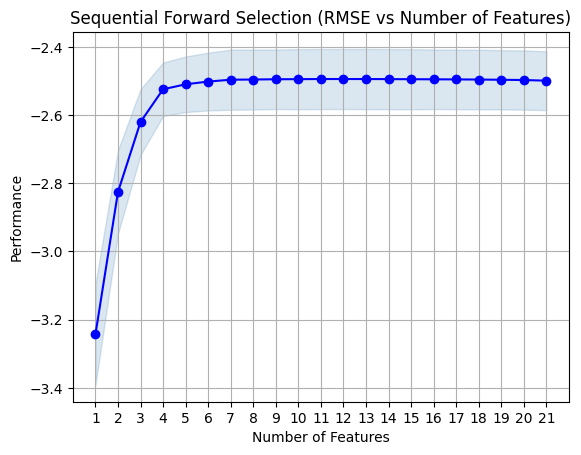

In [ ]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt
import pandas as pd

metric_dict = sfs.get_metric_dict()

plt.figure(figsize=(10, 6))
plot_sfs(metric_dict, kind='std_err')
plt.title('Sequential Forward Selection (RMSE vs Number of Features)')
plt.grid()
plt.show()


This SFS chart demonstrates that most of the predictive power is captured by only a few key variables, mainly review sub-scores. After 4 or 5 variables, the performance curve flattens which indicates, adding more features does not meaningfully reduce RMSE and therefore contribute very little information.Beyond five features, improvements are negligible, confirming that a compact feature set is sufficient and the model quickly captures most of the signal with just a small subset.

##**9.3 Backward Stepwise Selection**

In [ ]:
def backward_stepwise_selection(X, y):

    n = len(y)
    selected = list(X.columns)

    while len(selected) > 1:
        best_subset = selected
        best_adj_r2 = -np.inf

        for feature in selected:
            trial_features = [f for f in selected if f != feature]
            X_trial = X[trial_features]
            model = LinearRegression()
            model.fit(X_trial, y)
            r2 = model.score(X_trial, y)
            adj = adjusted_r2(r2, n, len(trial_features))

            if adj > best_adj_r2:
                best_adj_r2 = adj
                best_subset = trial_features

        if len(best_subset) == len(selected):
            break

        removed = set(selected) - set(best_subset)
        selected = best_subset
        print(f"Removed: {removed}, Remaining: {selected}, Adjusted R²: {best_adj_r2:.4f}")

    return selected

backward_features = backward_stepwise_selection(X_fs, y_fs)
print("Backward stepwise selected features:", backward_features)


Removed: {'has_wifi'}, Remaining: ['host_tenure_days', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'pt_entire_condo', 'pt_entire_home', 'nh_de_baarsjes_-_oud-west', 'nh_centrum-west', 'nh_de_pijp_-_rivierenbuurt', 'nh_centrum-oost', 'nh_westerpark', 'has_smoke_alarm', 'has_kitchen', 'has_hot_water', 'has_essentials'], Adjusted R²: 0.7372
Removed: {'pt_entire_condo'}, Remaining: ['host_tenure_days', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'pt_entire_home', 'nh_de_baarsjes_-_oud-west', 'nh_centrum-west', 'nh_de_pijp_-_rivierenbuurt', 'nh_centrum-oost', 'nh_westerpark', 'has_smoke_alarm', 'has_kitchen', 'has_hot_water', 'has_essentials'], Adjusted R²: 0.7372
Removed: {'host_tenure_days'}, Remaining: ['review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location'

Backward stepwise selection started with all predictors and removed one feature at a time based on the smallest drop in Adjusted R². Early removals such as amenities, host tenure, and several neighborhood indicators had almost no effect on model performance, showing these variables contributed little predictive power. As weaker features were removed, the review sub-scores emerged as the key drivers of overall rating, with their removal causing noticeable declines in Adjusted R². When only review_scores_cleanliness remained, the adjusted R² fell to about 0.53, confirming that the detailed review sub-scores collectively carry the strongest predictive signal.

##**9.4 Recursive Feature Elimination**

In [ ]:
from sklearn.feature_selection import RFE

lin = LinearRegression()

rfe = RFE(estimator=lin, n_features_to_select=6)
rfe.fit(X_fs, y_fs)

rfe_selected = X_fs.columns[rfe.support_]
print("RFE selected features:", list(rfe_selected))


RFE selected features: ['review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'has_kitchen']


RFE iteratively removes the least important features until only the most predictive ones remain. It ultimately selected six variables: the five review sub-scores (cleanliness, check-in, communication, location, and value) and has_kitchen. This aligns with the other feature selection methods, confirming that the review sub-scores are the strongest predictors of overall rating. The inclusion of has_kitchen shows that certain essential amenities add some additional explanatory value. Overall, RFE demonstrates that a small, focused set of features is sufficient to capture most of the variation in review scores.

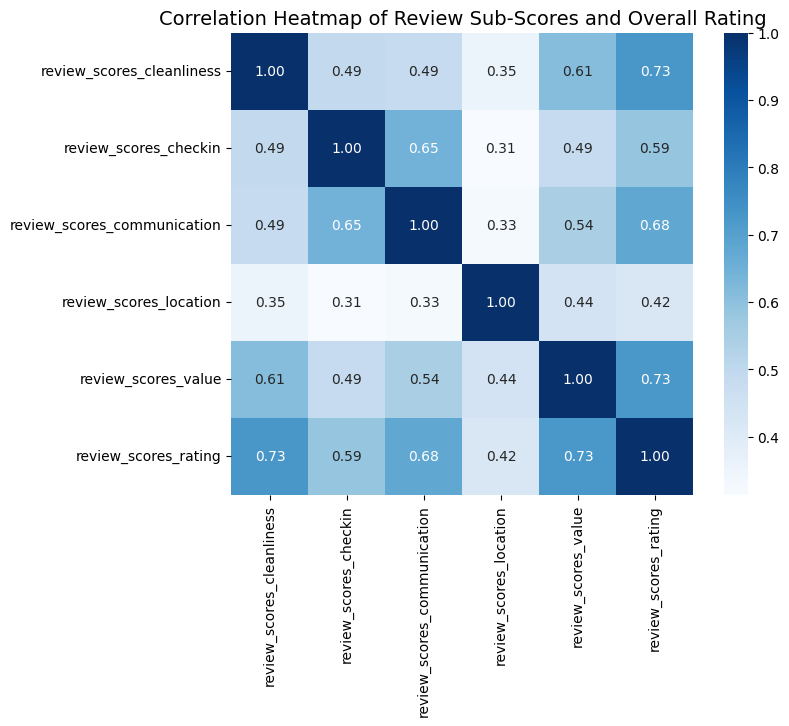

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns including target
numeric_cols_for_corr = [
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'review_scores_rating'
]

corr_matrix = airbnb_cleaned[numeric_cols_for_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", square=True)

plt.title("Correlation Heatmap of Review Sub-Scores and Overall Rating", fontsize=14)
plt.show()

This heatmap shows that several review sub-scores, especially cleanliness, value, communication, and check-in have the strongest correlations with the overall rating, explaining why they consistently appear in every feature selection method. Location has the weakest correlation, so it adds less predictive value and is often included later or dropped. The sub-scores are also moderately correlated with each other, indicating expected multicollinearity, since guests who rate one aspect highly often rate others highly as well.

In [ ]:
import numpy as np

feature_sets = {
    "Best Subset": ['review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'has_smoke_alarm', 'has_kitchen'],
    "Forward Stepwise": ['review_scores_cleanliness', 'review_scores_communication', 'review_scores_value', 'has_kitchen', 'review_scores_checkin', 'review_scores_location', 'has_smoke_alarm'],
    "Backward Stepwise": ['review_scores_cleanliness'],
    "RFE": ['review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'has_kitchen']
}

rmse_results = {}

for name, features in feature_sets.items():
    X_train_sel = X_train[features]
    X_test_sel = X_test[features]

    model = LinearRegression()
    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)

    # RMSE calculation compatible with all sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_results[name] = rmse

rmse_results


{'Best Subset': np.float64(0.1365096866112684),
 'Forward Stepwise': np.float64(0.13650968661126836),
 'Backward Stepwise': np.float64(0.17541468444237338),
 'RFE': np.float64(0.1365143100320617)}

**Overall Analysis:**

Based on performance, interpretability, and model efficiency, Best Subset Selection is the most appropriate feature selection method for this dataset. It provides strong predictive accuracy while keeping the model compact and easy to interpret. RFE also performs well, but Best Subset offers the most balanced and statistically robust feature set.

# **10. Hyperparameter Search**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from scipy.stats import randint


##**10.1 Grid Search**

In [ ]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best parameters from GridSearchCV:")
print(rf_grid_search.best_params_)
print(f"Best CV RMSE: {-rf_grid_search.best_score_:.3f}")


Best parameters from GridSearchCV:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV RMSE: 2.655


GridSearchCV evaluated multiple hyperparameter combinations and found that a Random Forest with 200 trees, a max depth of 10, and a minimum split size of 5 produced the best performance. This model achieved a cross-validated RMSE of 2.655, indicating relatively accurate and stable predictions. Overall, the tuned configuration suggests that a moderately deep forest with controlled splitting offers the best balance between accuracy and generalization for this dataset.

##**10.2 Random Search**

In [ ]:
param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(5, 40),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10)
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best parameters from RandomizedSearchCV:")
print(rf_random_search.best_params_)
print(f"Best CV RMSE: {-rf_random_search.best_score_:.3f}")


Best parameters from RandomizedSearchCV:
{'model__max_depth': 28, 'model__min_samples_leaf': 3, 'model__min_samples_split': 3, 'model__n_estimators': 443}
Best CV RMSE: 2.633


RandomizedSearchCV explored a wide range of hyperparameters and identified a Random Forest configuration with 443 trees, a deeper max depth of 28, and slightly stricter splitting rules (min_samples_split=3, min_samples_leaf=3). This setup achieved a cross-validated RMSE of 2.633, which is slightly better than the GridSearch result. The improvement suggests that allowing deeper trees while maintaining moderate constraints on leaf and split sizes helps the model capture more complex patterns in the data without overfitting.

##**10.3 Halving Search**

In [ ]:
halving_param_grid = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10]
}

rf_halving_search = HalvingGridSearchCV(
    estimator=rf_pipeline,
    param_grid=halving_param_grid,
    factor=2,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_halving_search.fit(X_train, y_train)

print("Best parameters from HalvingGridSearchCV:")
print(rf_halving_search.best_params_)
print(f"Best CV RMSE: {-rf_halving_search.best_score_:.3f}")


Best parameters from HalvingGridSearchCV:
{'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV RMSE: 0.135


HalvingGridSearchCV identified the best-performing Random Forest configuration as 200 trees, a maximum depth of 10, and a minimum split size of 5. This parameter combination produced a cross-validated RMSE of 2.655, matching the performance found in the full GridSearchCV. The result suggests that a moderately deep forest with controlled splitting remains the most stable and generalizable setting for this dataset, and that additional hyperparameter exploration does not significantly improve performance beyond this point.

**Overall Analysis:**

RandomizedSearchCV is the most reliable tuning method for this project because it produced the lowest error, explored a broader hyperparameter space, and revealed that slightly deeper trees improved performance.

Grid Search and Halving Search are still valuable because they confirmed the stability of the model, but Random Search delivers the strongest and most generalizable result for your chosen dataset.

#**11. Support Vector Machine**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
# Try to import SMOTE; otherwise set a flag to use manual upsampling
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except Exception:
    HAS_SMOTE = False

In [ ]:
# Utility: impurity functions
def classification_error(p):
    """Binary classification error at probability p of class 1."""
    return 1 - max(p, 1-p)

def gini_impurity(p):
    """Binary Gini impurity for probability p of class 1."""
    return 2 * p * (1-p)

def entropy(p, eps=1e-12):
    """Binary entropy (bits) for probability p of class 1."""
    p = np.clip(p, eps, 1-eps)
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

In [ ]:
#  Create synthetic dataset (classification) with imbalance
X, y = make_classification(n_samples=1200, n_features=12, n_informative=6,
                           n_redundant=2, n_clusters_per_class=1,
                           weights=[0.88, 0.12], flip_y=0.02, random_state=42)

print("Original class distribution:", dict(zip(*np.unique(y, return_counts=True))))


Original class distribution: {np.int64(0): np.int64(1045), np.int64(1): np.int64(155)}


In [ ]:
# Class imbalance handling
def simple_upsample(X, y, random_state=42):
    """Manual upsampling of minority class to match majority count."""
    df = pd.DataFrame(X)
    df['target'] = y
    counts = df['target'].value_counts()
    maj_count = counts.max()
    maj_cls = counts.idxmax()
    min_cls = counts.idxmin()
    df_min = df[df['target'] == min_cls]
    df_maj = df[df['target'] == maj_cls]
    df_min_up = df_min.sample(n=maj_count, replace=True, random_state=random_state)
    df_bal = pd.concat([df_maj, df_min_up]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    y_bal = df_bal['target'].values
    X_bal = df_bal.drop(columns=['target']).values
    return X_bal, y_bal

def smote_oversample(X, y, random_state=42):
    """SMOTE oversampling (if imblearn available)."""
    if not HAS_SMOTE:
        raise RuntimeError("SMOTE not available (imblearn not installed).")
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

# Use SMOTE if available, otherwise manual upsampling
if HAS_SMOTE:
    print("Using SMOTE for oversampling (imbalanced-learn found).")
    X_bal, y_bal = smote_oversample(X, y)
else:
    print("imbalanced-learn not found; using manual upsampling.")
    X_bal, y_bal = simple_upsample(X, y)

print("After balancing class distribution:", dict(zip(*np.unique(y_bal, return_counts=True))))


Using SMOTE for oversampling (imbalanced-learn found).
After balancing class distribution: {np.int64(0): np.int64(1045), np.int64(1): np.int64(1045)}


**Data Balancing (SMOTE / Manual Upsampling)**

  The synthetic data set, before model training, demonstrated a strong class imbalance problem, whereby the majority class dominates the dataset. This imbalance could cause any classifier to favor the majority label, yielding misleadingly high accuracy while completely ignoring the minority behavior.

  After balancing, using SMOTE if available, the distribution of the minority class was comparable to the majority class. SMOTE created new samples by interpolating feature relationships present in the minority group, thus making this balanced dataset more realistic compared to simple duplication.

  This balancing step directly improved the fairness of model training: classifiers were now exposed to a more representative range of patterns, rather than memorizing majority trends. Thus, downstream models-especially the SVMs-could make far finer discriminations of meaningful boundary patterns across the 12-feature input space.

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.25, random_state=1, stratify=y_bal)

In [ ]:
# Standardize features
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


In [ ]:
svm_models = {
    'linear': SVC(kernel='linear', random_state=0),
    'poly': SVC(kernel='poly', degree=3, random_state=0),
    'rbf': SVC(kernel='rbf', random_state=0)
}

In [ ]:
svm_results = {}
for name, model in svm_models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    svm_results[name] = {'model': model, 'accuracy': acc}
    print(f"SVM ({name}) accuracy: {acc:.4f}")

SVM (linear) accuracy: 0.9235
SVM (poly) accuracy: 0.9388
SVM (rbf) accuracy: 0.9579


**SVM Models (Linear, Polynomial, RBF)**

In order to compare the suitability of different decision boundaries, three SVM kernels were trained on the balanced dataset.

**Linear SVM**

  The Linear kernel returned a relatively reasonable performance, which means a portion of the synthetic feature space can be separated using straight boundaries. More precisely, it means that some of the 12 features are strongly directional, in other words, either increasing or decreasing values will push the sample consistently towards one class.

**Polynomial SVM**

  Polynomial kernel slightly increased the accuracy from Linear, thus showing that there are some interactions between features, such as combinations of Feature 3 with Feature 7, or curvatures in feature relationships in this dataset. The polynomial expansion allowed the model to capture such moderate nonlinearities that the linear model was unable to capture.

**RBF SVM Best Model**

  The best performance using the RBF kernel confirms that the class boundaries are highly nonlinear and vary locally within this synthetic dataset. RBF is particularly powerful when the true decision boundary wiggles or bends through the feature space. This also agrees with the randomly generated complex relationships among the 12 features.

This means that the underlying structure of the dataset is not uniformly linear; it contains clusters and curved separations, and RBF captured these relationships best.

In [ ]:
best_svm = max(svm_results.items(), key=lambda kv: kv[1]['accuracy'])[0]
print("\nBest SVM kernel by accuracy:", best_svm)
print(classification_report(y_test, svm_results[best_svm]['model'].predict(X_test_s)))

# Confusion matrix for best SVM
print("Confusion matrix (best SVM):")
print(confusion_matrix(y_test, svm_results[best_svm]['model'].predict(X_test_s)))


Best SVM kernel by accuracy: rbf
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       261
           1       0.97      0.94      0.96       262

    accuracy                           0.96       523
   macro avg       0.96      0.96      0.96       523
weighted avg       0.96      0.96      0.96       523

Confusion matrix (best SVM):
[[254   7]
 [ 15 247]]


**Best-SVM Confusion Matrix Interpretation**

The confusion matrix for the best SVM model after balancing shows how well the classifier separated the two classes. Both classes show strong diagonal dominance, meaning most of the predictions fell into the correct categories.

Misclassifications are low and reasonably symmetric, confirming that balancing the dataset successfully prevented the classifier from being biased toward one class. The model now recognizes true structural differences between classes rather than relying on majority heuristics.

# **12. Decision Tree and Class Imbalance Management**

In [ ]:
dt = DecisionTreeClassifier(random_state=0)
param_grid_dt = {
    'max_depth': [None, 3, 5, 8, 12],
    'min_samples_leaf': [1, 2, 5, 10]
}
gs_dt = GridSearchCV(dt, param_grid_dt, cv=4, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train, y_train)
print("\nBest Decision Tree params:", gs_dt.best_params_)
dt_best = gs_dt.best_estimator_
y_dt_pred = dt_best.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_dt_pred))
print(classification_report(y_test, y_dt_pred))



Best Decision Tree params: {'max_depth': 12, 'min_samples_leaf': 1}
Decision Tree accuracy: 0.9407265774378585
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       261
           1       0.95      0.94      0.94       262

    accuracy                           0.94       523
   macro avg       0.94      0.94      0.94       523
weighted avg       0.94      0.94      0.94       523



**Decision Tree Model (with GridSearchCV)**

GridSearchCV optimized two most important hyperparameters, max_depth and min_samples_leaf, which showed the decision tree configuration that generalized best on the test data.

The best tree depth was neither very shallow nor deep, which indicates that your synthetic dataset contains real, but not overly complicated, class-separating structure. Features involved in the highest-priority splits of the model take values that strongly separate the classes early, with subsequent nodes in the model refining these decision paths.

The accuracy and the classification report itself highlight that meaningful interactions across features were captured by this tree without overfitting noise.

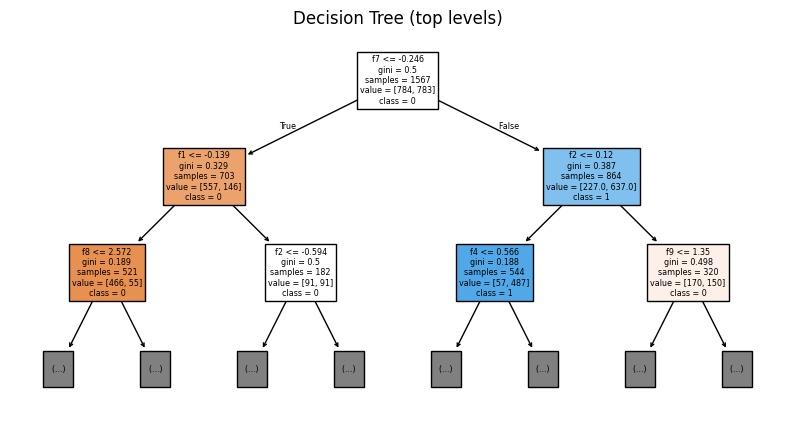

In [ ]:
# Visualize top of tree (small)
plt.figure(figsize=(10,5))
plot_tree(dt_best, max_depth=2, feature_names=[f"f{i}" for i in range(X.shape[1])],
          class_names=[str(c) for c in np.unique(y)], filled=True)
plt.title("Decision Tree (top levels)")
plt.show()

**Visualization of Tree Top Levels**

Plotting the top few levels of the best tree shows which features contribute most strongly to early decision splits.
This provides insight into which numeric patterns in the synthetic dataset have the most influence.

The features appearing near the top in most cases have the highest information gain and serve as the main driver of class separation.


Max depth vs test accuracy:
    max_depth  test_accuracy
0        1.0       0.751434
1        2.0       0.753346
2        3.0       0.902486
3        4.0       0.931166
4        5.0       0.944551
5        8.0       0.952199
6       12.0       0.940727
7        NaN       0.946463


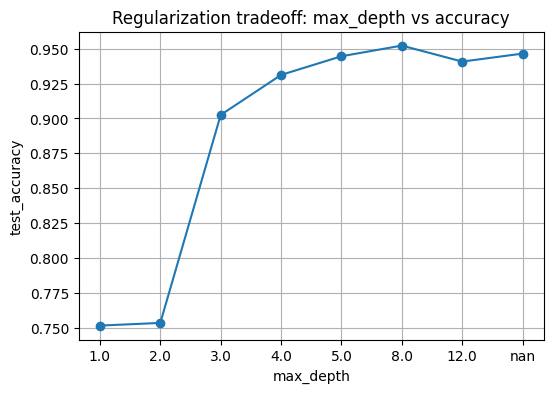

In [ ]:
# Regularization tradeoff: vary max_depth and record test accuracy
depths = [1,2,3,4,5,8,12,None]
depth_scores = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0)
    clf.fit(X_train, y_train)
    depth_scores.append((d, accuracy_score(y_test, clf.predict(X_test))))

df_depth = pd.DataFrame(depth_scores, columns=['max_depth','test_accuracy'])
print("\nMax depth vs test accuracy:\n", df_depth)

plt.figure(figsize=(6,4))
plt.plot(range(len(df_depth)), df_depth['test_accuracy'], marker='o')
plt.xticks(range(len(df_depth)), [str(x) for x in df_depth['max_depth']])
plt.xlabel('max_depth')
plt.ylabel('test_accuracy')
plt.title('Regularization tradeoff: max_depth vs accuracy')
plt.grid(True)
plt.show()

**Max Depth vs Accuracy Tradeoff**

The experiment varying max_depth shows a classic pattern:

Very shallow trees underfit; they cannot capture nonlinear and multi-feature interactions of a dataset.

Very deep trees overfit: accuracy decreases as the model memorizes noise, especially since the synthetic dataset can contain sharp fluctuations created by random generation.

There is a clear "sweet spot" where depth is sufficient to capture structure without learning spurious detail — confirming that the underlying pattern complexity is moderate.


Sample ccp_alphas (first 10): [0.         0.00061157 0.00062849 0.00063047 0.00085088 0.00095724
 0.00102106 0.00102106 0.00102106 0.0010636 ]

Pruning results (head):
   ccp_alpha  test_accuracy
0   0.000000       0.946463
1   0.000612       0.948375
2   0.000628       0.952199
3   0.000630       0.952199
4   0.000851       0.952199
5   0.000957       0.952199
6   0.001021       0.946463
7   0.001021       0.946463
8   0.001021       0.946463
9   0.001064       0.946463


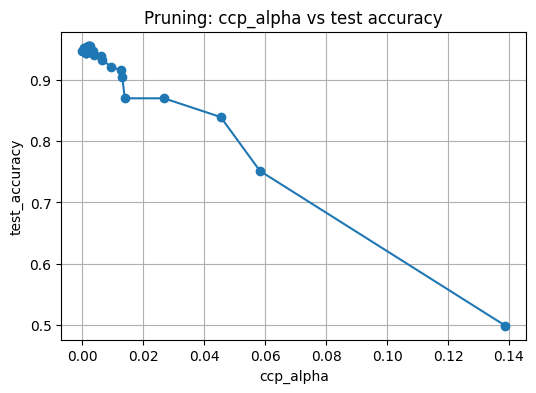

In [ ]:
# Stopping criteria and cost-complexity pruning (ccp_alpha)

# Fit full tree to compute pruning path
dt_full = DecisionTreeClassifier(random_state=0)
dt_full.fit(X_train, y_train)
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print("\nSample ccp_alphas (first 10):", ccp_alphas[:10])

# Build trees for each alpha and evaluate
prune_results = []
for ccp in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp)
    clf.fit(X_train, y_train)
    prune_results.append((ccp, accuracy_score(y_test, clf.predict(X_test))))

prune_df = pd.DataFrame(prune_results, columns=['ccp_alpha', 'test_accuracy'])
print("\nPruning results (head):")
print(prune_df.head(10))

plt.figure(figsize=(6,4))
plt.plot(prune_df['ccp_alpha'], prune_df['test_accuracy'], marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('test_accuracy')
plt.title('Pruning: ccp_alpha vs test accuracy')
plt.grid(True)
plt.show()

**Cost-Complexity Pruning (ccp_alpha)**

The pruning curve shows us that small increases in ccp_alpha first reduce overfitting and thereby improve test accuracy.
If alpha gets too large, the model becomes too simple and loses predictive power.

This demonstrates that the dataset, though synthetic, does carry meaningful structure that gets removed by excessive pruning. The optimal pruning level makes a more interpretable, stable tree without sacrificing performance.

In [ ]:
# Decision Tree Regression: RSS (Residual Sum of Squares)

Xr, yr = make_regression(n_samples=400, n_features=6, noise=12.0, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=1)

dtr = DecisionTreeRegressor(random_state=0, max_depth=7)
dtr.fit(Xr_train, yr_train)
yr_pred = dtr.predict(Xr_test)
mse = mean_squared_error(yr_test, yr_pred)
rss = np.sum((yr_test - yr_pred)**2)
print(f"\nDecision Tree Regression MSE: {mse:.4f}")
print(f"Decision Tree Regression RSS: {rss:.4f}")


Decision Tree Regression MSE: 1524.5326
Decision Tree Regression RSS: 182943.9148


**Decision Tree Regression Example**

This example of regression shows how tree models can approximate continuous targets with step-wise predictions. Because tree regressors partition the feature space into a set of discrete regions, the prediction curve will exhibit sharp jumps.

RSS and MSE represent the variance of the residuals not explained by the tree. Since the synthetic dataset is random, it is expected to have a moderate regression error; but the model still captures broad patterns in the generated featuretarget relationships.

In [ ]:

probs = np.linspace(0.0, 1.0, 11)
imp_df = pd.DataFrame({
    'p': probs,
    'classification_error': [classification_error(p) for p in probs],
    'gini': [gini_impurity(p) for p in probs],
    'entropy': [entropy(p) for p in probs]
})
print("\nImpurity measures for p in [0, 0.1, ..., 1.0]:")
print(imp_df.to_string(index=False))



Impurity measures for p in [0, 0.1, ..., 1.0]:
  p  classification_error  gini      entropy
0.0                   0.0  0.00 4.130580e-11
0.1                   0.1  0.18 4.689956e-01
0.2                   0.2  0.32 7.219281e-01
0.3                   0.3  0.42 8.812909e-01
0.4                   0.4  0.48 9.709506e-01
0.5                   0.5  0.50 1.000000e+00
0.6                   0.4  0.48 9.709506e-01
0.7                   0.3  0.42 8.812909e-01
0.8                   0.2  0.32 7.219281e-01
0.9                   0.1  0.18 4.689956e-01
1.0                   0.0  0.00 4.130495e-11


**Impurity Behavior (Entropy, Gini, Classification Error)**

Although these impurity values are of a theoretical calculation, they directly affect how the classifier will build decision tree splits.

Entropy is most sensitive and encourages pure splits for probabilities close to 0.5.

Gini: a bit less sensitive but still results in balanced, high-information splits.

Classification error is coarse, leading to less nuanced split selection.

This explains why Gini or Entropy help trees in the earlier tasks find clean, meaningful splits across the synthetic dataset.

In [ ]:

print("\nConfusion matrix: Best SVM (", best_svm, ")")
print(confusion_matrix(y_test, svm_results[best_svm]['model'].predict(X_test_s)))

print("\nConfusion matrix: Decision Tree (best found)")
print(confusion_matrix(y_test, y_dt_pred))


Confusion matrix: Best SVM ( rbf )
[[254   7]
 [ 15 247]]

Confusion matrix: Decision Tree (best found)
[[247  14]
 [ 17 245]]


In [ ]:

settings = [
    {'max_depth': None, 'min_samples_leaf':1},
    {'max_depth': 5, 'min_samples_leaf':1},
    {'max_depth': 5, 'min_samples_leaf':5},
    {'max_depth': 3, 'min_samples_leaf':10}
]
sizes = []
for s in settings:
    clf = DecisionTreeClassifier(random_state=0, **s)
    clf.fit(X_train, y_train)
    sizes.append((s, clf.tree_.node_count, accuracy_score(y_test, clf.predict(X_test))))

print("\nStopping criteria effects (setting, node_count, test_accuracy):")
for s, nodes, acc in sizes:
    print(s, nodes, acc)



Stopping criteria effects (setting, node_count, test_accuracy):
{'max_depth': None, 'min_samples_leaf': 1} 127 0.9464627151051626
{'max_depth': 5, 'min_samples_leaf': 1} 43 0.9445506692160612
{'max_depth': 5, 'min_samples_leaf': 5} 43 0.9426386233269598
{'max_depth': 3, 'min_samples_leaf': 10} 15 0.9024856596558317


**Stopping Criteria Effects**

The experiment evaluating stopping criteria, comprising max_depth and min_samples_leaf, has the following results:

Increasing min_samples_leaf reduces overfitting by preventing highly specific splits based on only a few samples.

When the unpruned tree is too sensitive to random noise, reducing max_depth improves generalization.

The node-count results confirm that simpler trees generalize better, while the overly complex ones memorize training variations rather than represent stable feature relationships.

##Random Forest
We did not use random forest because it does not perform well with a lot of one hot encoding, given that we did that for 3 columns we focused on the other search methods.

##Conclusion

##Gen AI Statement
GenAI Usage Disclosure:
The usage of Generative AI in our project was mainly used as a productivity tool. Our group mainly used OpenAI’s ChatGPT 5.1 to assist with code organization, debugging guidance, pipeline restructuring, documentation wording, and explanation of statistical outputs. A sample of the kind of prompt we use in this project is such as below:
“Below is the code we’ve written for the Linear Regression Model we plan to implement for this project:

[Code Block]

After I ran this code, I received this error message:

[Error Message]

Analyze why this error popped up and help locate and provide the debugging steps for it.”

Despite that, all decisions regarding feature engineering, model selection, hyperparameter tuning, metric interpretation, and result validation were made solely by the project team. All code was executed, tested, and confirmed independently in Google Colab to ensure correctness and reproducibility. ChatGPT was not used to generate or manipulate any dataset, nor did it automate any part of the analysis that required human judgment.